In [53]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import h5py
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

<h3> understanding and loading the dataset </h3>

In [54]:
with h5py.File("../datasets/cat_nocat/train_catvnoncat.h5", "r") as f:
    print("training set keys: ", list(f.keys()))
    train_x = np.array(f["train_set_x"])
    train_y = np.array(f["train_set_y"])

with h5py.File("../datasets/cat_nocat/test_catvnoncat.h5", "r") as f:
    print("test set keys: ", list(f.keys()))
    test_x = np.array(f["test_set_x"])
    test_y = np.array(f["test_set_y"])

training set keys:  ['list_classes', 'train_set_x', 'train_set_y']
test set keys:  ['list_classes', 'test_set_x', 'test_set_y']


In [55]:
print("training set size(examples, height, width, channels): ", train_x.shape)
print("test set size(examples, height, width, channels): ", test_x.shape)

training set size(examples, height, width, channels):  (209, 64, 64, 3)
test set size(examples, height, width, channels):  (50, 64, 64, 3)


y =  0


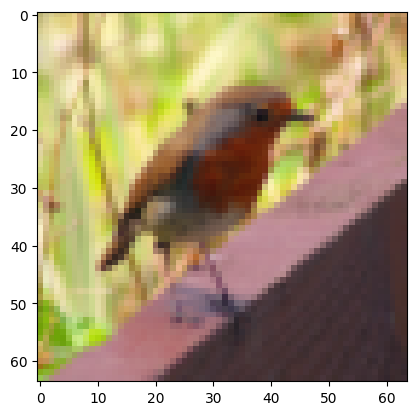

In [56]:
index = 10
plt.imshow(train_x[index])
print("y = ", train_y[index])

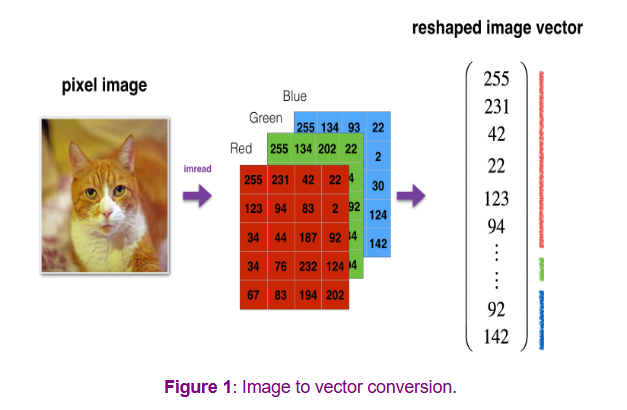

Normalize -> Flatten

In [57]:
#normalize
train_x = train_x/255.0
test_x = test_x/255.0

#flatten
train_x = train_x.reshape(train_x.shape[0], -1) #0th index consists of no.of examples, so keep it and flatten everything else
test_x = test_x.reshape(test_x.shape[0], -1)

print("train set x shape: ", train_x.shape)
print("test set x shape: ", test_x.shape)
print("training labels shape: ", train_y.shape)
print("test labels shape:", test_y.shape)

train set x shape:  (209, 12288)
test set x shape:  (50, 12288)
training labels shape:  (209,)
test labels shape: (50,)


In [58]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


When to use `.to(device)` — simple rule:

Everything that goes **into the model** must be on the same device as the model itself.
```
tensors → .to(device) 
model   → .to(device) 
both must match, otherwise PyTorch throws an error 
```

So you need .to(device) on:
```
Input tensors
Labels
Model
```

In [59]:
# numpy to tensor
train_x = torch.tensor(train_x, dtype = torch.float32).to(device)
test_x = torch.tensor(test_x, dtype = torch.float32).to(device)
train_y = torch.tensor(train_y, dtype = torch.float32).to(device)
test_y = torch.tensor(test_y, dtype = torch.float32).to(device)

<h3> Architecture of the model </h3>
General Rule for ANN Architecture:

For image classification with ANN, we usually follow a shrinking pyramid structure.

Example:
```
Input layer: 12288
Hidden layer 1: 512
Hidden layer 2: 128
Hidden layer 3: 32
Output layer: 1
```

In [60]:
from torch import nn
class cat_nocat_classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            
            nn.Linear(in_features=12288, out_features=512),
            nn.ReLU(),
            
            nn.Linear(in_features=512, out_features=128),
            nn.ReLU(),
            
            nn.Linear(in_features=128, out_features=32),
            nn.ReLU(),
            
            nn.Linear(in_features=32, out_features=1)
            
        )
        
    def forward(self, x):
        return self.model(x)

In [61]:
# model0 = cat_nocat_classifier().to(device)
# model0

In [75]:
#training the model, only epoch and no iteration because the model is small

def train_model(epochs, lr, train_x, train_y, model, iter_number):

    #setting the loss and optimizer function
    loss = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(params = model.parameters(), lr=lr)
    for epoch in range(epochs):
        model.train()
        
        y_pred_train = model(train_x).squeeze()
        
        cal_loss = loss(y_pred_train, train_y)
        
        optimizer.zero_grad()
        
        cal_loss.backward()
        
        optimizer.step()
        
        if epoch % (iter_number) == 0:
            print(f"for training iteration {epoch}, loss = {cal_loss.item():.4f}")
            

In [76]:
model1 = cat_nocat_classifier().to(device)
train_model(100, 0.01,train_x, train_y, model1, 10)

for training iteration 0, loss = 0.6938
for training iteration 10, loss = 0.6611
for training iteration 20, loss = 0.6122
for training iteration 30, loss = 0.8940
for training iteration 40, loss = 0.5069
for training iteration 50, loss = 0.4598
for training iteration 60, loss = 0.3268
for training iteration 70, loss = 0.2508
for training iteration 80, loss = 0.2852
for training iteration 90, loss = 0.1697


In [77]:
model1.eval()
with torch.inference_mode():
    logits = model1(test_x).squeeze()
    y_prob_test = torch.sigmoid(logits)
    y_pred_test = torch.round(y_prob_test)
    accuracy = (y_pred_test == test_y).float().mean() # == returns boolean value and float converts it to floating number then take mean
    

In [78]:
print("model accuracy = ", accuracy.item()*100)

model accuracy =  77.99999713897705


predicted class:  1.0


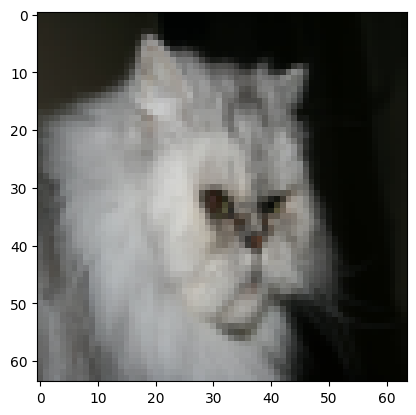

In [79]:
index_test = 10
plt.imshow(test_x[index_test].reshape(64,64,3).to("cpu"))
print("predicted class: ", y_pred_test[index_test].item())

In [84]:
torch.save(model1.state_dict(), "../saved_models/cat_nocat.pth")